<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Why Ensemble Learning?

1. Voting
   • Hard Voting
   • Soft Voting

2. Bagging (Revision)
   • Why Bagging?
   • Advantages
   • Limitations

3. Boosting
   • Why Boosting?
   • Weak Learner
   • Sequential Learning

4. AdaBoost
   • Sample Weights
   • Alpha
   • Working

5. Gradient Boosting
   • Residuals
   • Gradient Descent
   • Additive Model

6. XGBoost
   • Regularization
   • Second Order Taylor Expansion
   • Pruning
   • Missing Values

7. LightGBM
   • Leaf-wise Growth
   • Histogram Algorithm

8. CatBoost
   • Ordered Boosting
   • Categorical Features

9. Comparison
   • Random Forest vs AdaBoost
   • AdaBoost vs Gradient Boosting
   • Gradient Boosting vs XGBoost
   • XGBoost vs LightGBM vs CatBoost

10. Python Implementation
    (Titanic Dataset)

11. Questions

12. Summary

## 0. Why Ensemble Learning?

### Definition
Ensemble learning is a machine learning paradigm where multiple models (often called "weak learners" or "base learners") are trained to solve the same problem and combined to achieve better performance than any single model could achieve on its own. The core idea is that by aggregating the predictions of several individual models, the ensemble can reduce variance, bias, or improve prediction accuracy.

### What's the Need?
Traditional machine learning models, while powerful, often suffer from limitations such as high variance (overfitting to training data), high bias (underfitting), or simply not being robust enough for complex real-world data.

*   **Reducing Variance**: Some models, like decision trees, are highly sensitive to the specific training data. Small changes in the data can lead to very different tree structures. Ensemble methods like Bagging (e.g., Random Forest) average out these variations, leading to more stable and less overfitting models.
*   **Reducing Bias**: Other models, like linear regression, might be too simple to capture the underlying patterns in complex data, leading to high bias. Ensemble methods like Boosting (e.g., AdaBoost, Gradient Boosting) sequentially build models that correct the errors of previous ones, thereby reducing bias.
*   **Improving Predictive Accuracy**: By combining diverse perspectives from multiple models, ensemble methods can often achieve a higher predictive accuracy than any single constituent model. This is especially true when individual models make different types of errors.
*   **Robustness**: Ensembles are generally more robust to noise and outliers in the data because errors made by individual models are often cancelled out by correct predictions from other models.

### Math (Conceptual)
At its heart, ensemble learning is about combining multiple hypotheses (predictions) into a single, stronger hypothesis. Mathematically, this often involves some form of weighted averaging or voting among the base learners. If we have a set of $T$ base learners, $h_1, h_2, \dots, h_T$, their combined prediction $H(x)$ for an input $x$ can be:

*   **For Classification (Voting)**: A majority vote among the $h_t(x)$ predictions.
*   **For Regression (Averaging)**: A weighted average of the $h_t(x)$ predictions, i.e., $H(x) = \sum_{t=1}^{T} w_t h_t(x)$, where $w_t$ are weights assigned to each learner.

### Formula (General)
While specific formulas vary greatly depending on the ensemble technique (Bagging, Boosting, Stacking), the general idea is to aggregate individual predictions. For a simple weighted average ensemble in regression, the formula is:

$H(x) = \frac{1}{T} \sum_{t=1}^{T} h_t(x)$ (simple averaging)

or

$H(x) = \sum_{t=1}^{T} \alpha_t h_t(x)$ (weighted averaging, where $\sum \alpha_t = 1$)

For classification with hard voting, if $C_k$ is the class predicted by learner $k$, the final prediction is:

$H(x) = \text{mode}(\{C_1(x), C_2(x), \dots, C_T(x)\})$

### Advantages
*   **Higher Accuracy**: Often achieve better predictive performance than single models.
*   **Robustness**: More stable and less sensitive to noisy data or specific data splits.
*   **Reduced Overfitting/Underfitting**: Can effectively mitigate issues of high variance (Bagging) or high bias (Boosting).
*   **Generalization**: Tend to generalize better to unseen data.

### Disadvantages
*   **Increased Complexity**: Ensembles are inherently more complex than individual models, making them harder to interpret.
*   **Higher Computational Cost**: Training and predicting with multiple models can be computationally expensive and time-consuming.
*   **Storage Requirements**: Storing multiple models requires more memory.
*   **Diminishing Returns**: After a certain number of base learners, the performance improvement might become marginal while complexity continues to increase.

## 1. Voting

### Definition
Voting is one of the simplest and most intuitive ensemble techniques. It combines the predictions from multiple machine learning models (often of different types) to make a final prediction. The rationale behind voting is that by combining diverse models, the errors made by individual models can be compensated by the correct predictions of others, leading to a more robust and accurate ensemble.

### What's the Need?
Even well-tuned individual models can make mistakes. The need for voting arises from the desire to leverage the 'wisdom of crowds'. If a group of diverse models each make their best guess, and these guesses are combined, the aggregate prediction is often superior to any single model's prediction. This is particularly effective when individual models have different strengths and weaknesses or capture different aspects of the data.

### Math (Conceptual)
Conceptually, voting involves counting or averaging. For classification, it's about which class gets the most 'votes'. For regression, it's typically an average of the predicted values.

### Formula (General)
Let $h_1(x), h_2(x), \dots, h_M(x)$ be the predictions of $M$ individual models for a given input $x$.

*   **For Classification (General Voting Idea)**:
    The final prediction is typically the class that receives the most votes (hard voting) or the class with the highest average probability (soft voting).

*   **For Regression (Averaging)**:
    The final prediction is often the mean or median of the individual predictions:
    $H(x) = \frac{1}{M} \sum_{i=1}^{M} h_i(x)$ (mean)

### Visualization (Conceptual)
Imagine three classifiers, each drawing a different decision boundary. When using voting, the final decision boundary is a composite of these individual boundaries. In regions where models agree, the boundary is clear. In regions where they disagree, the majority (or average) determines the final outcome, often resulting in a smoother, more generalized boundary that reduces local irregularities of individual models.

### Advantages (General for Voting)
*   **Simplicity**: Easy to understand and implement.
*   **Versatility**: Can combine models of different types (heterogeneous ensembles).
*   **Improved Performance**: Often leads to better generalization and accuracy than individual models.
*   **Robustness**: Reduces the risk of relying on a single, potentially flawed model.

### Disadvantages (General for Voting)
*   **Model Selection**: Requires careful selection of diverse and reasonably accurate base models.
*   **No Interaction**: Models are trained independently; voting doesn't allow models to learn from each other's mistakes.
*   **Suboptimal for Weak Models**: If all base models are consistently bad in the same way, voting won't help much.

### 1.1 Hard Voting (Majority Class Voting)

#### Definition
Hard Voting, also known as majority class voting, is a classification ensemble technique where the final prediction for a given input is the class label that received the most votes from the individual base classifiers. Each classifier's prediction is treated equally, and only the predicted class label matters.

#### Formula
Given $M$ classifiers $h_1, h_2, \dots, h_M$, and their individual class predictions $C_1(x), C_2(x), \dots, C_M(x)$ for an input $x$, the final prediction $H(x)$ for Hard Voting is:

$H(x) = \text{mode}(\{C_1(x), C_2(x), \dots, C_M(x)\})$

If there is a tie, a tie-breaking rule is applied (e.g., choose the class with the lowest index, or a randomly selected class).

#### Advantages
*   **Simple and intuitive**: Easy to implement and understand.
*   **Effective for diverse models**: Works well when combining models that make different types of errors.
*   **No probability calibration needed**: Does not require individual models to output well-calibrated probabilities.

#### Disadvantages
*   **Ignores class probabilities**: Does not consider the confidence of individual classifiers in their predictions. A classifier that is 99% sure of its prediction has the same 'vote' as one that is 51% sure.
*   **Less sensitive to nuanced differences**: Can miss out on valuable information contained in probability estimates.

### 1.2 Soft Voting (Weighted Averaging of Probabilities)

#### Definition
Soft Voting, or weighted averaging of probabilities, is a classification ensemble technique where the final prediction is based on the average predicted probabilities for each class across all individual classifiers. The class with the highest average probability is chosen as the final prediction. Optionally, weights can be assigned to each classifier based on their individual performance.

#### Formula
Given $M$ classifiers, where each classifier $h_i$ outputs a probability $p_{i,c}(x)$ for class $c$ for input $x$. The final probability for each class $c$ is calculated as the average (or weighted average) of the individual probabilities:

$P_c(x) = \frac{1}{M} \sum_{i=1}^{M} p_{i,c}(x)$ (simple average)

Or, with weights $w_i$ for each classifier:

$P_c(x) = \frac{\sum_{i=1}^{M} w_i p_{i,c}(x)}{\sum_{i=1}^{M} w_i}$ (weighted average)

The final prediction $H(x)$ is the class with the highest average probability:

$H(x) = \arg\max_c P_c(x)$

#### Advantages
*   **Leverages confidence**: Takes into account the confidence (probability) of each classifier's prediction, leading to potentially more informed decisions.
*   **Smoother decision boundaries**: Often results in smoother decision boundaries than hard voting.
*   **Better performance**: Generally performs better than hard voting, especially when individual models provide good probability estimates.
*   **More flexible**: Allows for assigning weights to models, giving more influence to better-performing ones.

#### Disadvantages
*   **Requires probability output**: Individual classifiers must be able to output class probabilities (e.g., `predict_proba` in Scikit-learn).
*   **Probability calibration**: Performance can degrade if individual model probabilities are not well-calibrated.
*   **Computationally more intensive**: Calculating and averaging probabilities adds a slight overhead compared to simple majority voting.

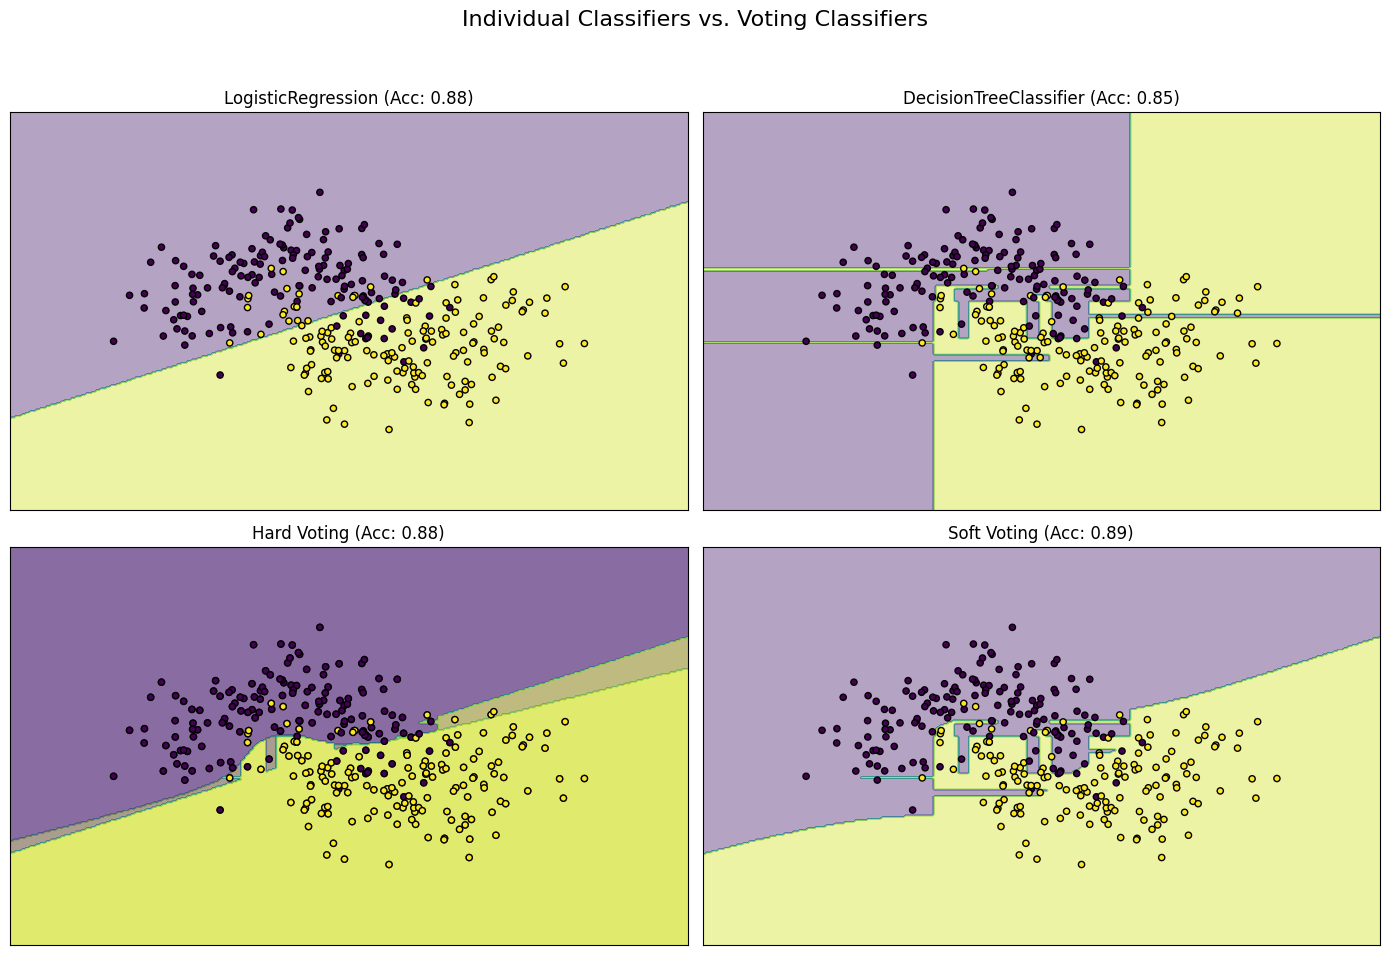

Accuracy of Logistic Regression: 0.88
Accuracy of Decision Tree: 0.85
Accuracy of SVC: 0.87
Accuracy of Hard Voting Classifier: 0.88
Accuracy of Soft Voting Classifier: 0.89


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Initialize diverse base classifiers
clf1 = LogisticRegression(random_state=1)
clf2 = DecisionTreeClassifier(random_state=1)
clf3 = SVC(kernel='poly', probability=True, random_state=1) # SVC needs probability=True for soft voting

# Create a function to plot decision boundaries
def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Individual Classifiers vs. Voting Classifiers', fontsize=16)

# Train and plot individual classifiers
for i, clf in enumerate([clf1, clf2, clf3]):
    clf_name = type(clf).__name__
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    row = i // 2
    col = i % 2
    plot_decision_boundary(clf, X, y, axes[row, col], f'{clf_name} (Acc: {acc:.2f})')

# Hard Voting Classifier
voting_clf_hard = VotingClassifier(estimators=[('lr', clf1), ('dt', clf2), ('svc', clf3)], voting='hard')
voting_clf_hard.fit(X_train, y_train)
y_pred_hard = voting_clf_hard.predict(X_test)
acc_hard = accuracy_score(y_test, y_pred_hard)
plot_decision_boundary(voting_clf_hard, X, y, axes[1, 0], f'Hard Voting (Acc: {acc_hard:.2f})')

# Soft Voting Classifier
voting_clf_soft = VotingClassifier(estimators=[('lr', clf1), ('dt', clf2), ('svc', clf3)], voting='soft')
voting_clf_soft.fit(X_train, y_train)
y_pred_soft = voting_clf_soft.predict(X_test)
acc_soft = accuracy_score(y_test, y_pred_soft)
plot_decision_boundary(voting_clf_soft, X, y, axes[1, 1], f'Soft Voting (Acc: {acc_soft:.2f})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print(f"Accuracy of Logistic Regression: {accuracy_score(y_test, clf1.predict(X_test)):.2f}")
print(f"Accuracy of Decision Tree: {accuracy_score(y_test, clf2.predict(X_test)):.2f}")
print(f"Accuracy of SVC: {accuracy_score(y_test, clf3.predict(X_test)):.2f}")
print(f"Accuracy of Hard Voting Classifier: {acc_hard:.2f}")
print(f"Accuracy of Soft Voting Classifier: {acc_soft:.2f}")


## 2. Bagging (Bootstrap Aggregating)

### Definition
Bagging, short for **Bootstrap Aggregating**, is an ensemble meta-algorithm designed to improve the stability and accuracy of machine learning algorithms. It reduces variance and helps to avoid overfitting. It involves training multiple instances of the same base learning algorithm on different subsets of the training data, and then combining their predictions, typically through averaging for regression or majority voting for classification.



### 2.1 Why Bagging? (What's the Need?)
Bagging was introduced to address the problem of **high variance** in powerful but unstable models, particularly decision trees. Models with high variance are very sensitive to the specific data they are trained on; small changes in the training set can lead to significantly different models and predictions. This often results in overfitting, where the model performs well on the training data but poorly on unseen data.

The core idea of Bagging is to:
1.  **Reduce Variance**: By training multiple models on different bootstrapped samples of the data and averaging their predictions, Bagging effectively 'smooths out' the individual models' tendencies to overfit to specific patterns in their respective training subsets.
2.  **Improve Stability**: The aggregation process makes the overall ensemble model more robust and less susceptible to noise or outliers in the data.

### How it Works (Working)
1.  **Bootstrapping**: From the original training dataset (of size `N`), Bagging creates `k` new subsets of data. Each subset is generated by randomly sampling `N` data points *with replacement* from the original dataset. This means some data points may appear multiple times in a single subset, while others may not appear at all (out-of-bag samples).
2.  **Base Model Training**: A base learner (e.g., a decision tree) is trained independently on each of these `k` bootstrapped datasets.
3.  **Aggregation**: After all `k` models are trained:
    *   For **regression tasks**, the predictions from each model are averaged to produce the final ensemble prediction.
    *   For **classification tasks**, the predictions are combined through majority voting (the class predicted by the most models wins) or by averaging probabilities (soft voting).



### 2.2. Math
Consider a regression problem. If we have $k$ predictors $h_1(x), h_2(x), \dots, h_k(x)$, each trained on a different bootstrapped sample, the Bagging predictor $H(x)$ is simply the average:

$H(x) = \frac{1}{k} \sum_{i=1}^{k} h_i(x)$

The reduction in variance comes from the fact that the expected value of the average of independent identically distributed (i.i.d.) random variables has a smaller variance than that of an individual variable. While the base learners in Bagging are not perfectly independent, the bootstrapping process introduces enough diversity to significantly reduce the overall variance of the ensemble.

### Formula (General)
Let $Y$ be the true output and $\hat{f}_i(x)$ be the prediction of the $i$-th base learner trained on the $i$-th bootstrapped sample. The ensemble prediction $H(x)$ is defined as:

*   **For Regression:**
    $H(x) = \frac{1}{k} \sum_{i=1}^{k} \hat{f}_i(x)$

*   **For Classification (Hard Voting):**
    $H(x) = \text{mode}(\{ \hat{f}_1(x), \hat{f}_2(x), \dots, \hat{f}_k(x) \})$

*   **For Classification (Soft Voting - if base models provide probabilities):**
    $H(x) = \arg\max_c \sum_{i=1}^{k} P(y=c | x, \hat{f}_i)$



### 2.3. Visualization (Conceptual)
Imagine having a dataset with some noise. A single complex model might try to fit all the noise, leading to an irregular decision boundary (high variance). Bagging works by:
1.  **Creating many slightly different datasets**: Each bootstrapped sample is a slightly altered version of the original, causing individual models to learn slightly different decision boundaries.
2.  **Averaging/Voting**: When these slightly different (and potentially overfitted) decision boundaries are averaged or voted upon, the noise-induced irregularities tend to cancel each other out, resulting in a smoother, more generalized decision boundary that is less prone to overfitting.



#### Working Code with Graph (Conceptual, Python with Scikit-learn)

While a full interactive graph generation is complex for this explanation, here's how you'd typically implement and visualize the concept:

*   **Expected Graph**: The left plot (Single Decision Tree) will likely show a very irregular and possibly overfitted decision boundary, trying to perfectly separate the training points, even misclassifying some test points. The right plot (Bagging Classifier) will show a much smoother and more generalized decision boundary, indicating a reduction in variance and improved generalization on unseen data.

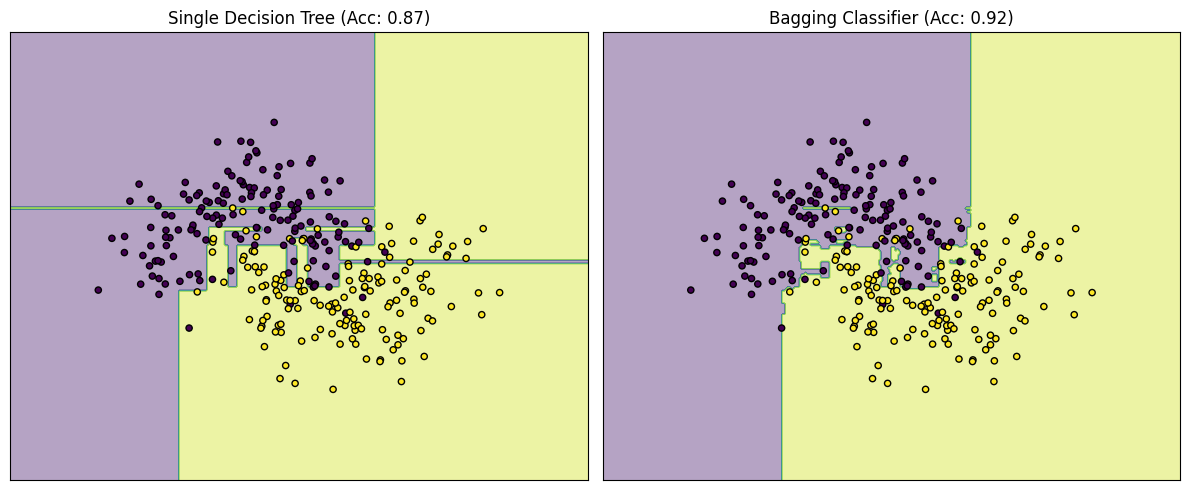

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Generate a synthetic dataset
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Define a function to plot decision boundaries
def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Train a single Decision Tree (high variance)
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
plot_decision_boundary(single_tree, X, y, axes[0], f'Single Decision Tree (Acc: {single_tree.score(X_test, y_test):.2f})')

# 2. Train a Bagging Classifier (reduced variance)
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    n_estimators=100,  # Number of base estimators
    max_samples=1.0,   # Sample 100% of data with replacement
    bootstrap=True,    # Use bootstrapping
    n_jobs=-1,         # Use all available cores
    random_state=42
)
bag_clf.fit(X_train, y_train)
plot_decision_boundary(bag_clf, X, y, axes[1], f'Bagging Classifier (Acc: {bag_clf.score(X_test, y_test):.2f})')

plt.tight_layout()
plt.show()


### 2.4. Advantages
*   **Reduces Variance**: This is the primary advantage, making Bagging effective for unstable models (like decision trees) that tend to overfit.
*   **Improved Accuracy**: Often leads to better predictive performance compared to individual base models.
*   **Robustness**: More resilient to noisy data and outliers.
*   **Parallelizable**: The training of individual base models is independent, meaning they can be trained in parallel, which can significantly speed up the training process.
*   **Out-of-Bag (OOB) Evaluation**: Since each base model is trained on a subset of data, there's always a portion of the training data (out-of-bag samples) that wasn't used. These OOB samples can be used to estimate the generalization error without needing a separate validation set, similar to cross-validation.

### 2.5 Limitations (Cons)
*   **Interpretability**: Combining multiple models makes the overall ensemble less interpretable than a single base model, making it harder to understand *why* a particular prediction was made.
*   **Computational Cost**: While parallelizable, training many base models still requires more computational resources and time than training a single model.
*   **Increased Storage**: Storing multiple models requires more memory.
*   **Bias Reduction**: Bagging primarily focuses on reducing variance. It does not significantly reduce bias. If the base learner itself is inherently biased, Bagging won't help much in correcting that bias.
*   **No Significant Performance Boost for Stable Models**: For models that already have low variance (e.g., linear regression), Bagging might offer only marginal improvements, and the increased complexity might not be justified.

### Comparison with Similar Algorithms
*   **vs. Boosting**: While both are ensemble methods, Bagging and Boosting differ significantly. Bagging aims to reduce variance by averaging independent models. Boosting, on the other hand, aims to reduce bias by sequentially training models, where each new model tries to correct the errors of the previous ones. Bagging builds diverse models in parallel; Boosting builds dependent models in series. Random Forest is an extension of Bagging, while AdaBoost and Gradient Boosting are examples of Boosting.

## 3. Boosting

### Definition
Boosting is an ensemble meta-algorithm that converts weak learners into strong learners. It works by training a series of weak models sequentially, where each new model in the sequence is built to correct the errors of the previous ones. The predictions from all these weak learners are then combined, typically through a weighted majority vote (for classification) or a weighted sum (for regression), to produce a final, highly accurate prediction.

### 3.1 Why Boosting? (What's the Need?)
While Bagging primarily focuses on reducing variance, **Boosting aims to reduce bias**. Many simple models, known as 'weak learners' (e.g., shallow decision trees), inherently have high bias and are unable to capture complex patterns in the data. They often underfit the training data.

The need for Boosting arises from:
1.  **Addressing Bias**: By iteratively building models that focus on the mistakes of their predecessors, Boosting can create a highly accurate model even from simple, biased base learners.
2.  **Improving Predictive Power**: It adaptively changes the weights of misclassified training samples, giving more importance to difficult-to-classify points in subsequent iterations.
3.  **Complex Decision Boundaries**: It can learn complex non-linear relationships in the data that individual weak learners cannot.

### How it Works (Working - General Idea)
1.  **Initial Model**: An initial weak model is trained on the entire dataset.
2.  **Identify Errors**: The algorithm identifies the data points that were misclassified or poorly predicted by the current model.
3.  **Adjust Weights/Focus**: Subsequent weak models are trained by giving more weight or attention to these misclassified/poorly predicted data points.
4.  **Iterative Training**: This process is repeated for a specified number of iterations, with each new model attempting to correct the errors of the ensemble formed by all previous models.
5.  **Combine Predictions**: Finally, the predictions of all weak learners are combined, usually with different weights assigned to each learner, to form a strong predictor.

### Math (Conceptual)
At a high level, Boosting iteratively constructs an additive model. Suppose we have a set of weak learners $h_t(x)$ and we want to combine them into a strong learner $H(x)$. The general form of the strong learner is often:

$H(x) = \sum_{t=1}^{T} \alpha_t h_t(x)$

where $\alpha_t$ is the weight assigned to the $t$-th weak learner. The key is that $\alpha_t$ and the parameters of $h_t(x)$ are determined sequentially to minimize an overall loss function. Each $h_t(x)$ attempts to model the 'residual' errors of the previous ensemble $H_{t-1}(x)$.

### Formula (General)
The specific formula depends heavily on the boosting algorithm (AdaBoost, Gradient Boosting, etc.). However, the general principle involves minimizing a loss function $L(y, H(x))$ where $H(x)$ is an additive model.

For a general additive model:
$H(x) = H_{t-1}(x) + \alpha_t h_t(x)$

The goal at each step $t$ is to find $h_t(x)$ and $\alpha_t$ that best reduce the error when added to the existing ensemble $H_{t-1}(x)$.

### Visualization (Conceptual)
Imagine a dataset with two classes (positive and negative). A weak learner might draw a simple line, misclassifying several points. In the next iteration, the points that were misclassified (or have higher errors) are given more emphasis. The next weak learner then focuses on these points, drawing another simple line. This process continues, with each new line trying to fix the mistakes. When all lines are combined, they form a complex decision boundary that can accurately separate the classes.

### Advantages
*   **High Accuracy**: Often achieves very high predictive accuracy, especially on complex datasets.
*   **Bias Reduction**: Excellent at reducing bias, allowing the ensemble to learn intricate patterns.
*   **Robust to Overfitting (to some extent)**: While boosting can overfit if too many iterations are used, it is generally robust and can provide good generalization with proper tuning.

### Disadvantages
*   **Sequential Nature**: Since models are trained sequentially, it's computationally more expensive and cannot be parallelized like Bagging.
*   **Sensitive to Noise/Outliers**: Because each subsequent model focuses on misclassified points, Boosting can be sensitive to noisy data and outliers, as they might be heavily weighted, leading to overfitting to the noise.
*   **Complex Hyperparameter Tuning**: Often requires careful tuning of multiple hyperparameters (e.g., number of estimators, learning rate, depth of trees).
*   **Interpretation**: Like other ensemble methods, the final boosted model can be less interpretable than a single decision tree.

### Comparison with Similar Algorithms
*   **vs. Bagging**: The fundamental difference is that Bagging combines independent models to reduce variance, while Boosting combines dependent models sequentially to reduce bias. Bagging can be parallelized; Boosting cannot. Bagging models average predictions; Boosting models combine weighted predictions with a focus on correcting previous errors.
*   **vs. Stacking**: Stacking also combines multiple models, but it uses a meta-learner to learn how to combine the predictions of base models, rather than a fixed aggregation method like voting or weighted sums.

### 3.2 Weak Learner

#### Definition
A weak learner, also known as a weak classifier, is a machine learning model that performs only slightly better than random chance on a given task. In the context of binary classification, a weak classifier has an error rate slightly less than 0.5 (or slightly more than 50% accuracy). Examples include shallow decision trees (e.g., decision stumps, which are decision trees with only one split), simple linear classifiers, or even rules that check a single feature.

#### What's the Need?
The brilliance of Boosting lies in its ability to combine many such weak learners to form a single, very strong learner. The need for weak learners in Boosting is that they are:
1.  **Simple and Fast**: Easy and quick to train, even on re-weighted datasets.
2.  **Less Prone to Overfitting Individually**: Because they are simple, they have high bias but low variance, making them good candidates for algorithms that aim to reduce bias iteratively.
3.  **Feasible to Optimize**: Finding the best weak learner at each step of the boosting process is computationally manageable.

#### Visualization (Conceptual)
Imagine trying to classify points in a 2D plane. A weak learner (like a decision stump) would just draw one horizontal or vertical line to split the data. It will certainly make many mistakes. Boosting takes many such simple lines, each focusing on previous mistakes, and combines them to form a complex, curved boundary.

#### Advantages
*   **Computational Efficiency**: Fast to train due to their simplicity.
*   **Foundation for Boosting**: They are the building blocks that Boosting algorithms use to construct powerful models.
*   **Interpretability (of individual learners)**: Individual weak learners are often very interpretable.

#### Disadvantages
*   **High Bias**: By themselves, they are often too simple to capture complex relationships and will underfit the data.
*   **Low Accuracy**: Their individual predictive power is limited.

### 3.3 Sequential Learning

#### Definition
Sequential learning, in the context of Boosting, refers to the process where individual weak learners are trained one after another, in a sequence. Each new learner in the sequence is built in a way that it pays more attention to the training instances that were misclassified or incorrectly predicted by the *ensemble of all previously trained learners*.

#### What's the Need?
Sequential learning is the core mechanism by which Boosting algorithms progressively improve their performance and reduce bias. It's needed because:
1.  **Error Correction**: It allows subsequent models to learn from the mistakes of their predecessors, iteratively reducing the overall error of the ensemble.
2.  **Adaptive Learning**: The process adaptively re-weights data points or targets residuals, forcing the learners to focus on the 'harder' examples.
3.  **Building Complexity**: By adding simple models incrementally, the ensemble builds a more complex and accurate decision boundary over time.

#### Visualization (Conceptual)
Consider a series of students learning a complex subject. In sequential learning, the first student learns the basics and makes mistakes. The next student then specifically studies the areas where the first student struggled, and so on. Each subsequent student benefits from the knowledge of the previous ones, ultimately leading to a collective mastery of the subject.

#### Advantages
*   **Error Minimization**: Highly effective at progressively minimizing the training error by focusing on difficult examples.
*   **Effective for Bias Reduction**: A key enabler for Boosting's ability to reduce bias.

#### Disadvantages
*   **No Parallelization**: The sequential nature means that training cannot be done in parallel, making it slower than Bagging for large datasets or many estimators.
*   **Dependency on Previous Models**: Errors in early models can propagate and potentially affect the performance of later models, though Boosting algorithms are designed to mitigate this.

## 4. AdaBoost (Adaptive Boosting)

### Definition
AdaBoost, short for Adaptive Boosting, is one of the earliest and most popular boosting algorithms. It is an iterative ensemble method that combines multiple "weak learners" (typically shallow decision trees, often called "decision stumps" when they have only one split) into a single "strong learner." The key idea behind AdaBoost is to give more weight to misclassified samples in successive iterations, forcing subsequent weak learners to focus on these harder-to-classify examples.

### What's the Need?
AdaBoost addresses the need to improve the performance of simple, weak models that individually might only perform slightly better than random chance. Traditional models can struggle with complex decision boundaries or imbalanced datasets. AdaBoost tackles this by:
1.  **Iterative Error Correction**: Systematically correcting the errors made by previous models.
2.  **Focusing on Difficult Samples**: By adjusting sample weights, it ensures that subsequent learners pay more attention to samples that are harder to classify, thereby improving overall accuracy.
3.  **Building a Strong Classifier from Weak Ones**: It demonstrates the powerful concept that a highly accurate classifier can be constructed by combining many simple, inaccurate ones.

### Math (Conceptual)
AdaBoost builds an additive model. At each iteration $m$, a new weak learner $h_m(x)$ is trained. The critical aspect is how this new learner is trained: it's trained on a re-weighted version of the training data. The samples that were misclassified by the previous ensemble are given higher weights, and correctly classified samples get lower weights.

After training $h_m(x)$, its performance is evaluated, and a weight $\alpha_m$ (often called `amount of say` or `contribution`) is assigned to it. More accurate weak learners get higher $\alpha_m$.

The final strong classifier $H(x)$ is a weighted sum of all the weak learners:
$H(x) = \text{sign}\left(\sum_{m=1}^{M} \alpha_m h_m(x)\right)$

### Formula (General for Binary Classification)
Let $N$ be the number of training samples, $y_i \in \{-1, +1\}$ be the true labels, and $h_m(x)$ be the prediction of the $m$-th weak learner. Let $D_m(i)$ be the weight of the $i$-th training sample at iteration $m$.

**Initialization:**
Set initial sample weights $D_1(i) = \frac{1}{N}$ for all $i=1, \dots, N$.

**For $m = 1, \dots, M$ (number of weak learners):**
1.  **Train weak learner**: Train $h_m(x)$ using distribution $D_m$.
2.  **Calculate error**: Calculate the error rate $\epsilon_m$ of $h_m(x)$ with respect to $D_m$:
    $\epsilon_m = \sum_{i=1}^{N} D_m(i) \mathbb{I}(h_m(x_i) \ne y_i)$ where $\mathbb{I}(\cdot)$ is the indicator function.
3.  **Calculate learner weight (Alpha)**: Calculate the coefficient $\alpha_m$ (amount of say) for $h_m(x)$:
    $\alpha_m = \frac{1}{2} \ln\left(\frac{1 - \epsilon_m}{\epsilon_m}\right)$
    (Note: If $\epsilon_m = 0.5$, $\alpha_m = 0$. If $\epsilon_m = 0$, $\alpha_m = \infty$. If $\epsilon_m = 1$, $\alpha_m = -\infty$.)
4.  **Update sample weights**: Update the weights for the next iteration:
    $D_{m+1}(i) = D_m(i) \exp(-\alpha_m y_i h_m(x_i))$
    Normalize the weights so that $\sum_{i=1}^{N} D_{m+1}(i) = 1$.

**Final Strong Classifier:**
$H(x) = \text{sign}\left(\sum_{m=1}^{M} \alpha_m h_m(x)\right)$

### Visualization (Conceptual)
Imagine a scatter plot of two classes. The first decision stump makes a simple split. The points it misclassifies are made larger (i.e., their weights are increased). The next decision stump then tries to better separate these larger points. This process repeats, with each stump focusing on previous errors. The final combined classifier then forms a complex boundary that accurately separates the classes.

### Advantages
*   **High Accuracy**: Often achieves high accuracy, especially when using simple, weak learners.
*   **Relatively Simple to Implement**: Compared to some other boosting algorithms, the core AdaBoost logic is straightforward.
*   **No Hyperparameter Tuning for Weak Learners**: Can work well with very simple weak learners (e.g., decision stumps) without much tuning needed for the base models themselves.
*   **Adaptive**: Automatically focuses on hard-to-classify examples.

### Disadvantages
*   **Sensitive to Noisy Data and Outliers**: Since it heavily weights misclassified points, it can be sensitive to noise and outliers, leading to overfitting if not handled carefully.
*   **Sequential Nature**: Models are trained sequentially, which makes it slow and prevents parallelization.
*   **Can Overfit**: If the number of weak learners is too large, or if the base learners are too complex, AdaBoost can overfit the training data.
*   **Requires Binary Classification**: The original AdaBoost algorithm is designed for binary classification, though extensions exist for multi-class problems.

### Comparison with Similar Algorithms
*   **vs. Bagging**: AdaBoost (Boosting) sequentially focuses on correcting errors and reduces bias, whereas Bagging combines independent models to reduce variance. AdaBoost is not parallelizable; Bagging is. AdaBoost assigns weights to both samples and learners, while Bagging typically doesn't.
*   **vs. Gradient Boosting**: AdaBoost minimizes an exponential loss function, while Gradient Boosting is more generalized and can minimize arbitrary differentiable loss functions by fitting to pseudo-residuals.
*   **vs. Random Forest**: Random Forest is a Bagging algorithm. It builds multiple deep decision trees in parallel, reducing variance. AdaBoost builds shallow decision trees sequentially, reducing bias.

### 4.1 Sample Weights

#### Definition
In AdaBoost, sample weights are numerical values assigned to each data point in the training set. These weights determine the influence of each sample during the training of a weak learner. Initially, all samples usually have equal weights. However, after each iteration, the weights are adjusted: samples that were misclassified by the current ensemble receive increased weights, while correctly classified samples receive decreased weights.

#### What's the Need?
Sample weights are fundamental to AdaBoost's adaptive nature. They are needed to:
1.  **Direct Focus**: Force subsequent weak learners to concentrate on the samples that are difficult to classify, thereby correcting the errors of the previous learners.
2.  **Prioritize Errors**: Give more importance to errors made on specific data points, ensuring that the overall ensemble gradually reduces these errors.
3.  **Adaptive Learning**: Facilitate the iterative improvement process, allowing the algorithm to "learn from its mistakes."

#### Math (Update Formula)
As described in the general formula for AdaBoost, the update rule for sample weights $D_{m+1}(i)$ is:

$D_{m+1}(i) = D_m(i) \exp(-\alpha_m y_i h_m(x_i))$

followed by normalization so that $\sum_{i=1}^{N} D_{m+1}(i) = 1$.

*   If $y_i h_m(x_i) = 1$ (correctly classified), then $D_{m+1}(i) = D_m(i) \exp(-\alpha_m)$. Since $\alpha_m > 0$ for a weak learner better than random, $\exp(-\alpha_m) < 1$, so the weight decreases.
*   If $y_i h_m(x_i) = -1$ (misclassified), then $D_{m+1}(i) = D_m(i) \exp(\alpha_m)$. Since $\alpha_m > 0$, $\exp(\alpha_m) > 1$, so the weight increases.

#### Visualization (Conceptual)
Imagine data points on a graph. Initially, all points are the same size. After a weak learner incorrectly classifies some points, those misclassified points visibly grow larger (representing their increased weight). The next weak learner will then prioritize fitting a decision boundary that correctly classifies these now larger points.

#### Advantages
*   **Adaptive Learning**: Enables the algorithm to adaptively focus on challenging examples.
*   **Error Correction**: Directly contributes to the ensemble's ability to correct previous errors.

#### Disadvantages
*   **Sensitivity to Outliers**: If there are noisy or outlying data points, they might be consistently misclassified, leading to their weights being drastically increased. This can cause the model to overfit to these outliers.

### 4.2 Alpha (Learner Weight / Amount of Say)

#### Definition
In AdaBoost, $\alpha_m$ (alpha) is the weight assigned to each weak learner $h_m(x)$ in the final ensemble. It quantifies the 'amount of say' or the contribution of that particular weak learner to the final strong classifier. The value of $\alpha_m$ is determined by the weak learner's accuracy on the *re-weighted* training data from its specific iteration.

#### What's the Need?
Alpha is crucial for the final aggregation of weak learners. It's needed because:
1.  **Differentiated Contribution**: Not all weak learners are equally good. Alpha ensures that more accurate weak learners have a greater influence on the final prediction, while less accurate ones have less influence.
2.  **Performance Reflection**: It directly reflects the performance of the weak learner; the better it performs (lower error $\epsilon_m$), the higher its alpha, and thus its importance.

#### Math (Formula)
As given in the general AdaBoost algorithm, the formula for $\alpha_m$ is:

$\alpha_m = \frac{1}{2} \ln\left(\frac{1 - \epsilon_m}{\epsilon_m}\right)$

Where $\epsilon_m$ is the error rate of the $m$-th weak learner. Let's analyze this:
*   If $\epsilon_m = 0.5$ (random guessing), then $\alpha_m = \frac{1}{2} \ln\left(\frac{0.5}{0.5}\right) = \frac{1}{2} \ln(1) = 0$. The learner has no say.
*   If $\epsilon_m \to 0$ (perfect learner), then $\frac{1 - \epsilon_m}{\epsilon_m} \to \infty$, so $\alpha_m \to \infty$. A perfect learner gets infinite say.
*   If $\epsilon_m \to 1$ (always wrong), then $\frac{1 - \epsilon_m}{\epsilon_m} \to 0$, so $\alpha_m \to -\infty$. A perfectly wrong learner gets a large negative say, effectively reversing its prediction.

#### Visualization (Conceptual)
Imagine a line of experts, each giving their opinion. Alpha is like a badge indicating how trustworthy or influential each expert's opinion is. A highly accurate expert gets a large, shiny badge (high alpha) and their opinion is given more weight. A less accurate expert gets a smaller, dimmer badge (low alpha).

#### Advantages
*   **Weighted Aggregation**: Allows for intelligent combination of weak learners based on their individual performance.
*   **Improved Accuracy**: Contributes significantly to the final model's high accuracy by prioritizing more reliable weak predictions.

#### Disadvantages
*   **Relies on Error Rate**: Its calculation directly depends on the weak learner's error rate, which can be sensitive to small changes or noisy data.

### 4.3 Working (Detailed Steps)

#### How it Works (Step-by-step)
Let's walk through the AdaBoost algorithm for binary classification with labels $\{ -1, +1 \}$:

1.  **Initialize Sample Weights**: Assign an equal weight $D_1(i) = 1/N$ to each of the $N$ training samples $(x_i, y_i)$.

2.  **Iterate for $M$ Weak Learners**: For each $m = 1, 2, \dots, M$:
    a.  **Train Weak Learner**: Train a weak learner (e.g., a decision stump) $h_m(x)$ on the training data. The learner's objective is to minimize its error with respect to the current sample weights $D_m$. That is, it tries to correctly classify the samples that currently have high weights.
    b.  **Calculate Error Rate (Weighted)**: Evaluate the error rate $\epsilon_m$ of $h_m(x)$ on the *weighted* training data:
        $\epsilon_m = \sum_{i=1}^{N} D_m(i) \mathbb{I}(h_m(x_i) \ne y_i)$
    c.  **Calculate Learner Weight (Alpha)**: Compute the weight $\alpha_m$ for this weak learner:
        $\alpha_m = \frac{1}{2} \ln\left(\frac{1 - \epsilon_m}{\epsilon_m}\right)$
    d.  **Update Sample Weights**: Adjust the weights of the training samples for the next iteration. Increase weights for misclassified samples and decrease weights for correctly classified samples:
        $D_{m+1}(i) = D_m(i) \exp(-\alpha_m y_i h_m(x_i))$
    e.  **Normalize Weights**: Normalize the updated sample weights so they sum to 1:
        $D_{m+1}(i) \leftarrow D_{m+1}(i) / \sum_{j=1}^{N} D_{m+1}(j)$

3.  **Combine Weak Learners**: After all $M$ weak learners are trained, combine them into a final strong classifier $H(x)$ using their respective $\alpha_m$ weights:
    $H(x) = \text{sign}\left(\sum_{m=1}^{M} \alpha_m h_m(x)\right)$

*   **Expected Graph**: The left plot will show a very simple, linear decision boundary from a single decision stump, likely with many misclassifications (low accuracy). The right plot, representing the AdaBoost classifier, will show a much more complex and curved decision boundary, accurately separating the classes, demonstrating how combining many weak stumps can create a powerful classifier with significantly higher accuracy.

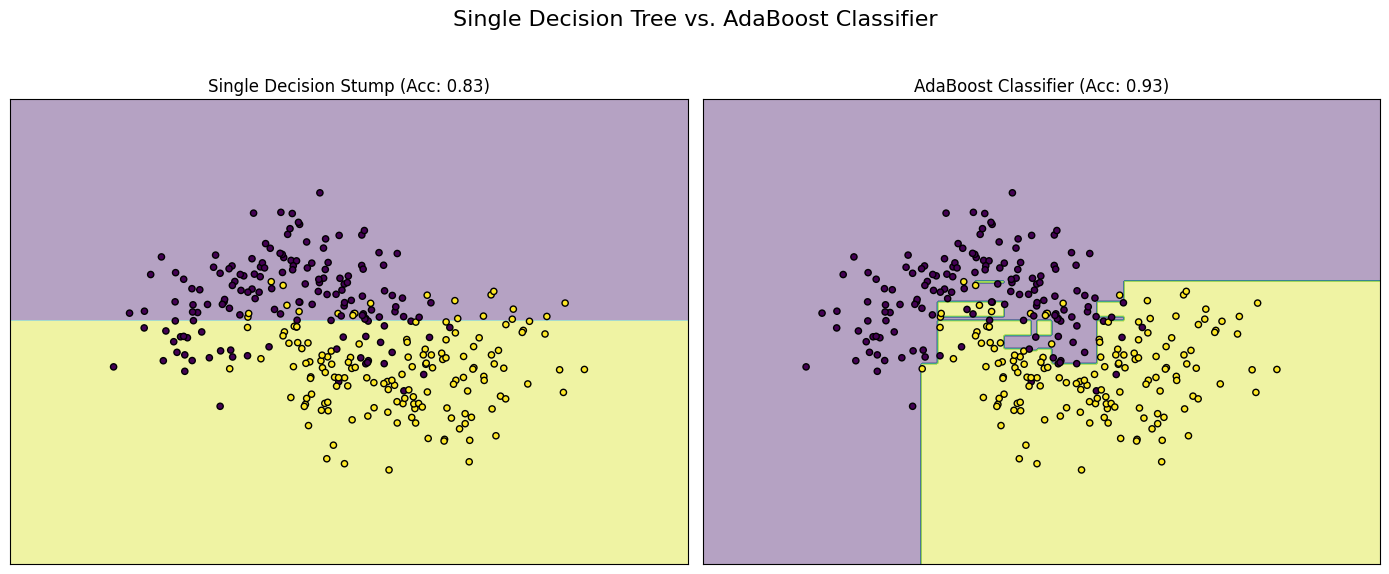

Accuracy of Single Decision Stump: 0.83
Accuracy of AdaBoost Classifier: 0.93


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
# Convert labels from {0, 1} to {-1, 1} for AdaBoost's theoretical formula
y_ada = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y_ada, random_state=42)

# Define a function to plot decision boundaries
def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Single Decision Tree vs. AdaBoost Classifier', fontsize=16)

# 1. Train a single Decision Tree (shallow, weak learner)
single_tree = DecisionTreeClassifier(max_depth=1, random_state=42) # Max_depth=1 makes it a decision stump
single_tree.fit(X_train, y_train)
y_pred_single = single_tree.predict(X_test)
acc_single = accuracy_score(y_test, y_pred_single)
plot_decision_boundary(single_tree, X, y_ada, axes[0], f'Single Decision Stump (Acc: {acc_single:.2f})')

# 2. Train an AdaBoost Classifier
adaboost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42), # Use decision stumps as base estimators
    n_estimators=100, # Number of weak learners
    learning_rate=1.0, # Contribution of each tree to the ensemble
    random_state=42
)
adaboost_clf.fit(X_train, y_train)
y_pred_ada = adaboost_clf.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)
plot_decision_boundary(adaboost_clf, X, y_ada, axes[1], f'AdaBoost Classifier (Acc: {acc_ada:.2f})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Accuracy of Single Decision Stump: {acc_single:.2f}")
print(f"Accuracy of AdaBoost Classifier: {acc_ada:.2f}")

## 5. Gradient Boosting

### Definition
Gradient Boosting is a powerful and popular ensemble machine learning technique that builds an ensemble of weak prediction models, typically decision trees, in a sequential manner. Unlike AdaBoost which focuses on sample weights, Gradient Boosting builds models by iteratively adding new models that *minimize the errors (residuals)* of the previous ensemble. It does this by fitting the new models to the *negative gradient of the loss function* with respect to the ensemble's predictions, essentially performing gradient descent in function space.

### What's the Need?
Gradient Boosting was developed to generalize the boosting concept beyond specific loss functions (like the exponential loss in AdaBoost). It addresses the need for:
1.  **Flexibility**: To be applicable to a wider range of machine learning problems (regression, classification, ranking) and various loss functions.
2.  **Higher Accuracy**: Often achieves state-of-the-art predictive performance on structured data.
3.  **Robustness**: By optimizing directly on the loss function's gradient, it offers a more direct approach to minimizing prediction errors.

### Math (Conceptual)
At its core, Gradient Boosting views the ensemble learning process as an optimization problem. It seeks to find a function $F(x)$ that minimizes a given loss function $L(y, F(x))$.

Starting with an initial model $F_0(x)$, at each step $m$, it trains a new weak learner $h_m(x)$ to predict the *negative gradient* of the loss function. This negative gradient is often referred to as a "pseudo-residual." The ensemble is then updated by adding a scaled version of this new weak learner:

$$F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)$$

Where $\gamma_m$ is the step size or learning rate, chosen to optimally minimize the loss.

### Formula (General)
Let $L(y, F(x))$ be a differentiable loss function. The goal is to find $F(x)$ that minimizes the expected value of $L$.

1. **Initialize the model**: Start with a constant function $F_0(x)$ that minimizes $L$:

$$
F_0(x)=\arg\min_{\gamma}\sum_{i=1}^{N}L(y_i,\gamma)
$$

2. **For $m = 1, \dots, M$ (number of iterations):**

   a. **Compute pseudo-residuals**: Calculate the negative gradient of the loss function with respect to the current model $F_{m-1}(x)$ for each sample $i$:

$$
r_{im}
=
-
\frac{\partial L(y_i,F(x_i))}
{\partial F(x_i)}
\Bigg|_{F(x)=F_{m-1}(x)}
$$

   b. **Fit weak learner**: Train a new weak learner $h_m(x)$ (e.g., a decision tree) to fit these pseudo-residuals $r_{im}$.

   c. **Compute optimal step size**: Find the optimal step size (or learning rate) $\gamma_m$ that minimizes the loss when adding $h_m(x)$ to the current model:

$$
\gamma_m
=
\arg\min_{\gamma}
\sum_{i=1}^{N}
L\!\left(
y_i,\,
F_{m-1}(x_i)+\gamma\,h_m(x_i)
\right)
$$

   d. **Update the model**: Update the overall ensemble model:

$$
F_m(x)
=
F_{m-1}(x)
+
\gamma_m h_m(x)
$$

3. **Final Model**: The final boosted model is $F_M(x)$.

### Visualization (Conceptual)
Imagine trying to fit a curve through data points. Gradient Boosting starts with a flat line (average prediction). Then, it calculates the 'downhill' direction (negative gradient or residuals) from each point to the current line. It then fits a small curve (a weak learner) to these downhill directions. This small curve is added to the line, making it slightly better. This process repeats, gradually shaping the curve to fit the data better and better, iteratively moving towards the minimum of the loss function.

### Advantages
*   **High Accuracy**: Consistently achieves high predictive accuracy across a wide range of tasks and datasets.
*   **Flexibility**: Can be used with various loss functions (e.g., squared error, logistic loss, huber loss) and base learners, making it highly adaptable.
*   **Handles Different Data Types**: Can naturally handle mixed data types (numerical, categorical).
*   **Robust to Outliers (with certain loss functions)**: Using loss functions like Huber or quantile loss can make it more robust to outliers than AdaBoost.

### Disadvantages
*   **Sequential Training**: Models are built sequentially, making it difficult to parallelize and computationally expensive.
*   **Sensitive to Overfitting**: Can overfit if the number of estimators is too high or the learning rate is too aggressive, especially with noisy data. Careful tuning of hyperparameters is crucial.
*   **Less Interpretable**: The final model is a complex combination of many weak learners, making it difficult to interpret.
*   **Computational Cost**: More computationally intensive and memory-demanding than AdaBoost due to fitting to gradients and keeping track of complex tree structures.

### Comparison with Similar Algorithms
*   **vs. AdaBoost**: AdaBoost focuses on sample weights, making subsequent learners focus on misclassified samples. Gradient Boosting focuses on fitting to the *residuals* or negative gradients of the loss function. Gradient Boosting is more general and can optimize arbitrary differentiable loss functions.
*   **vs. Random Forest**: Random Forest uses Bagging (parallel training of independent trees) to reduce variance. Gradient Boosting uses Boosting (sequential training, each correcting previous errors) to reduce bias. Gradient Boosting typically achieves higher accuracy but is more prone to overfitting and slower to train than Random Forest.

### 5.1 Residuals

#### Definition
In the context of Gradient Boosting for regression, **residuals** refer to the differences between the actual observed values ($y_i$) and the predicted values ($F_{m-1}(x_i)$) of the current ensemble model. Formally, for a regression problem using a squared error loss, the residual for sample $i$ at iteration $m$ is $y_i - F_{m-1}(x_i)$. More generally, in Gradient Boosting, the algorithm fits new models to *pseudo-residuals*, which are the negative gradients of the loss function.

#### What's the Need?
Residuals (or pseudo-residuals) are the primary signal that Gradient Boosting uses to iteratively improve its predictions. They are needed to:
1.  **Identify Remaining Error**: They tell the algorithm *how much* and *in what direction* the current model is wrong for each data point.
2.  **Guide Subsequent Learners**: Each new weak learner is trained to predict these residuals (or pseudo-residuals). By doing so, it learns to correct the errors of the previous ensemble.
3.  **Iterative Refinement**: This continuous process of fitting to residuals ensures that the overall model gradually minimizes the overall prediction error.

#### Math (Squared Error Loss Example)
For a regression problem with a squared error loss function $L(y, F(x)) = \frac{1}{2}(y - F(x))^2$, the negative gradient (pseudo-residual) is:

$$r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)} = -\left[ \frac{\partial}{\partial F(x_i)} \frac{1}{2}(y_i - F(x_i))^2 \right]_{F(x) = F_{m-1}(x)}$$

$$= - [ (y_i - F(x_i)) \cdot (-1) ]_{F(x) = F_{m-1}(x)}$$

$$= y_i - F_{m-1}(x_i)$$

In this specific case, the pseudo-residual is exactly the traditional residual. This is why Gradient Boosting with squared error loss is often described as iteratively fitting to residuals.

#### Visualization (Conceptual)
Imagine plotting predicted values vs. actual values. If the predictions were perfect, all points would lie on a 45-degree line. Residuals are the vertical distances from each point to this line. If your current model has a systematic bias (e.g., always underpredicts for high values), the residuals will show this pattern. The next weak learner will then try to model *that pattern in the residuals*.

#### Advantages
*   **Clear Error Signal**: Provides a direct measure of how much error the current model is making for each instance.
*   **Direct Optimization**: Enables the algorithm to directly optimize a given loss function by targeting its gradient.

#### Disadvantages
*   **Loss Function Differentiability**: Requires the loss function to be differentiable (or at least sub-differentiable for some variants).

### 5.2 Gradient Descent

#### Definition
Gradient Descent is a first-order iterative optimization algorithm used to find the local minimum of a differentiable function. In the context of machine learning, it's widely used to minimize the cost function (or loss function) of a model by iteratively adjusting the model's parameters in the direction opposite to the gradient of the loss function.

#### What's the Need?
Gradient Boosting uses the principle of gradient descent, but instead of descending in the parameter space of a single model, it descends in a *function space*. The need for gradient descent in Gradient Boosting is to:
1.  **Minimize Loss**: Provide a systematic way to minimize the overall loss function of the ensemble.
2.  **Iterative Improvement**: Guide the sequential training process by determining the "best" direction (i.e., the negative gradient) in which to add new weak learners.
3.  **Generalization**: Allow Gradient Boosting to optimize *any* differentiable loss function, making it highly flexible.

#### Math (Conceptual)
In traditional gradient descent, you update parameters $\theta$ as:
$$\theta_{new} = \theta_{old} - \eta \nabla L(\theta_{old})$$
where $\eta$ is the learning rate and $\nabla L(\theta_{old})$ is the gradient of the loss function with respect to the parameters.

In Gradient Boosting, this concept is extended to function space. Instead of parameters, we are optimizing the ensemble function $F(x)$. At each step, we identify the direction of steepest descent by computing the negative gradient of the loss function with respect to $F(x)$, and then fit a weak learner to approximate this direction.

#### Visualization (Conceptual)
Imagine being blindfolded on a mountain and trying to reach the lowest point (the minimum loss). Gradient descent tells you to take small steps in the steepest downhill direction. In Gradient Boosting, each weak learner is like taking one such step, gradually moving the ensemble's prediction towards the actual values, thereby minimizing the overall prediction error.

#### Advantages
*   **General Optimization Strategy**: Applicable to any differentiable loss function.
*   **Foundation for Boosting**: Provides the mathematical framework for iteratively improving the model.

#### Disadvantages
*   **Local Minima**: Like traditional gradient descent, it can get stuck in local minima if the loss function is non-convex (though this is less of an issue in typical Gradient Boosting contexts).
*   **Step Size (Learning Rate)**: Requires careful selection of the learning rate ($\gamma_m$) to ensure convergence without overshooting or getting stuck.

### 5.3 Additive Model

#### Definition
An additive model, in the context of Gradient Boosting, is a model where the final prediction is a sum of predictions from multiple, simpler models. Gradient Boosting constructs its strong learner as an additive ensemble of weak learners, typically decision trees.

#### What's the Need?
Additive models are needed in Gradient Boosting because:
1.  **Iterative Construction**: They allow the ensemble to be built step-by-step. Each new weak learner is simply added to the existing sum.
2.  **Error Correction**: Each added weak learner is designed to correct the errors made by the sum of all previous weak learners.
3.  **Flexibility and Interpretability (of components)**: While the final additive model can be complex, its components (the weak learners) are typically simple and relatively interpretable.

#### Math (Formula)
The additive model construction in Gradient Boosting follows the form:

$$F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)$$

Where:
*   $F_m(x)$ is the ensemble model at iteration $m$.
*   $F_{m-1}(x)$ is the ensemble model from the previous iteration.
*   $h_m(x)$ is the $m$-th weak learner.
*   $\gamma_m$ is the weight (or learning rate) of the $m$-th weak learner.

Starting from $F_0(x)$ (an initial constant prediction), the model expands to:
$$F_M(x) = F_0(x) + \sum_{m=1}^{M} \gamma_m h_m(x)$$

#### Visualization (Conceptual)
Imagine building a complex structure by adding one brick at a time. Each brick (weak learner) contributes to the overall structure (the strong learner). In an additive model, the final shape is the sum of all these individual bricks, each placed in a specific way to improve the overall design.

#### Advantages
*   **Modularity**: Allows for easy addition of new learners to improve the model.
*   **Interpretability (at component level)**: Individual weak learners can be simple and interpretable.
*   **Powerful Ensembles**: The additive nature, combined with the sequential error correction, results in very powerful predictive models.

#### Disadvantages
*   **Final Model Complexity**: The overall ensemble can be very complex, making global interpretation challenging.
*   **Sequential Dependency**: Relies on the sequential nature of boosting, making parallel training difficult.

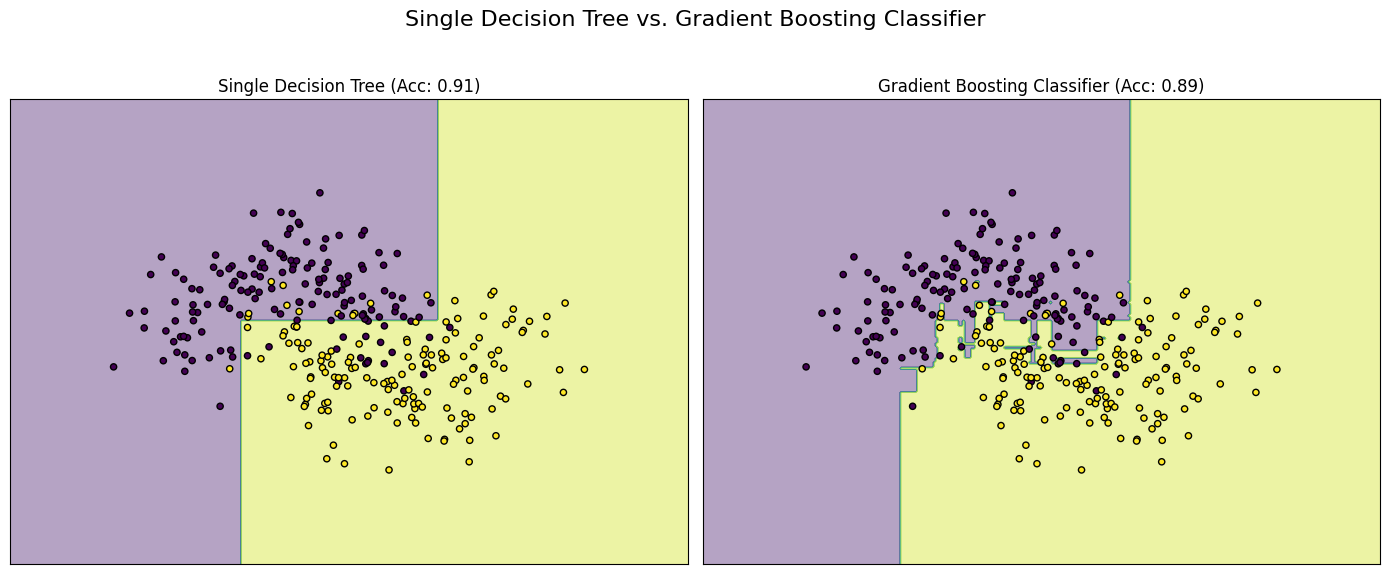

Accuracy of Single Decision Tree: 0.91
Accuracy of Gradient Boosting Classifier: 0.89


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Define a function to plot decision boundaries
def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Single Decision Tree vs. Gradient Boosting Classifier', fontsize=16)

# 1. Train a single Decision Tree (shallow, weak learner)
single_tree = DecisionTreeClassifier(max_depth=3, random_state=42) # A bit deeper than a stump for comparison
single_tree.fit(X_train, y_train)
y_pred_single = single_tree.predict(X_test)
acc_single = accuracy_score(y_test, y_pred_single)
plot_decision_boundary(single_tree, X, y, axes[0], f'Single Decision Tree (Acc: {acc_single:.2f})')

# 2. Train a Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=100,      # Number of boosting stages
    learning_rate=0.1,     # Step size shrinkage
    max_depth=3,           # Depth of individual regression trees
    random_state=42
)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
plot_decision_boundary(gb_clf, X, y, axes[1], f'Gradient Boosting Classifier (Acc: {acc_gb:.2f})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Accuracy of Single Decision Tree: {acc_single:.2f}")
print(f"Accuracy of Gradient Boosting Classifier: {acc_gb:.2f}")

## 6. XGBoost

### Definition
XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost is known for its speed and performance, often being the tool of choice for winning machine learning competitions and handling large datasets. It extends the traditional Gradient Boosting algorithm by adding regularization terms to control overfitting and by introducing a more principled approach to tree construction.

### What's the Need?
While Gradient Boosting is powerful, it can be computationally expensive and prone to overfitting, especially on noisy datasets. XGBoost addresses these limitations and needs by providing:
1.  **Performance and Speed**: Highly optimized C++ implementation, parallel processing, and efficient handling of sparse data.
2.  **Regularization**: Built-in L1 (Lasso) and L2 (Ridge) regularization to prevent overfitting, which is crucial for achieving better generalization performance.
3.  **Improved Tree Pruning**: A more sophisticated tree pruning mechanism (post-pruning) compared to traditional greedy algorithms.
4.  **Handling Missing Values**: An inherent ability to handle missing values by learning the best direction for missing values.
5.  **Flexibility**: Supports various objective functions, including regression, classification, and ranking problems.

### Math (Conceptual)
XGBoost refines Gradient Boosting by using a more sophisticated objective function that includes a regularization term. This objective function is optimized using a Taylor expansion to approximate the loss function up to the second order. This allows for a more precise and stable optimization process.

At each iteration, XGBoost attempts to find a new weak learner (a regression tree) that optimally reduces the overall objective function. The objective function at iteration $t$ is typically defined as:

$$\text{Obj}^{(t)} = \sum_{i=1}^{n} L(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$

Where:
*   $L$ is the differentiable loss function.
*   $\hat{y}_i^{(t-1)}$ is the prediction of the model from the previous $(t-1)$ iterations.
*   $f_t(x_i)$ is the new weak learner (tree) being added at iteration $t$.
*   $\Omega(f_t)$ is the regularization term for the new tree $f_t$, which penalizes complexity.

The key insight is to use a second-order Taylor expansion to approximate the loss function, making the optimization process tractable and more accurate.

### Formula (Objective Function)
The objective function at iteration $t$ that XGBoost minimizes is:

$$\text{Obj}^{(t)} = \sum_{i=1}^{n} [L(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i)] + \Omega(f_t)$$

Where:
*   $g_i = \frac{\partial L(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)}}$ (the first-order gradient of the loss function).
*   $h_i = \frac{\partial^2 L(y_i, \hat{y}_i^{(t-1)})}{\partial (\hat{y}_i^{(t-1)})^2}$ (the second-order gradient of the loss function).
*   $\Omega(f_t) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$ is the regularization term.
    *   $T$ is the number of leaves in the tree $f_t$.
    *   $w_j$ is the score (output value) of the $j$-th leaf.
    *   $\gamma$ and $\lambda$ are regularization parameters.

After removing constant terms $L(y_i, \hat{y}_i^{(t-1)})$, the simplified objective to optimize becomes:

$$\text{Obj}^{(t)} = \sum_{i=1}^{n} [g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i)] + \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$$

This objective function allows XGBoost to evaluate the quality of a tree structure and find the optimal leaf scores. During tree construction, it greedily searches for the best split by evaluating the gain for each possible split, which is derived from this objective.

### Visualization (Conceptual)
Imagine building a decision tree where, at each split, you're not just trying to minimize immediate error, but also considering the *cost of complexity*. XGBoost builds trees deeper and wider than a simple decision stump, but it has mechanisms (regularization, pruning) to prevent these complex trees from overfitting. Visually, its decision boundaries are often very intricate but smooth, capable of capturing complex non-linear relationships while still generalizing well.

### Advantages
*   **High Performance**: State-of-the-art accuracy on many tabular datasets.
*   **Speed and Efficiency**: Optimized C++ backend, parallel processing, and cache awareness.
*   **Regularization**: Built-in L1/L2 regularization prevents overfitting.
*   **Flexibility**: Supports custom loss functions, different base learners, and various scenarios.
*   **Handles Missing Values**: Can automatically learn the best direction for missing values.
*   **Tree Pruning**: Implements depth-first search for tree building and then prunes back based on gain values, which is more effective than greedy pre-pruning.

### Disadvantages
*   **Complexity**: More parameters to tune compared to simpler models, requiring careful hyperparameter optimization.
*   **Sequential Nature**: Still sequential in essence, although parallelization techniques are used within tree construction, the overall boosting process is sequential.
*   **Memory Consumption**: Can be memory-intensive, especially with large datasets and many trees.
*   **Interpretability**: As an ensemble of many complex trees, the final model is difficult to interpret directly.

### 6.1 Regularization

#### Definition
Regularization in machine learning refers to techniques used to prevent overfitting by adding a penalty term to the loss function. This penalty discourages complex models, for example, by penalizing large coefficients or too many leaves in a tree. XGBoost incorporates both L1 (Lasso) and L2 (Ridge) regularization directly into its objective function during tree construction.

#### What's the Need?
Traditional Gradient Boosting can be prone to overfitting, especially when building deep trees or using many estimators. Regularization is needed to:
1.  **Prevent Overfitting**: By penalizing complexity, regularization helps the model generalize better to unseen data.
2.  **Control Model Complexity**: It provides a mechanism to explicitly manage the trade-off between bias and variance.
3.  **Improve Robustness**: Makes the model less sensitive to noise in the training data.

#### Math (Formula)
XGBoost's objective function includes a regularization term $\Omega(f_t)$ for each tree $f_t$:

$$\Omega(f_t) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$$

Where:
*   $T$ is the number of leaves in the tree $f_t$.
*   $w_j$ is the output score (prediction) of the $j$-th leaf.
*   $\gamma$ is the regularization parameter for the number of leaves (L1 regularization on tree structure).
*   $\lambda$ is the regularization parameter for the leaf weights (L2 regularization on leaf scores).

*   **$\gamma$ (min_split_loss or gamma in XGBoost)**: This parameter specifies the minimum loss reduction required to make a further partition on a leaf node of the tree. A larger $\gamma$ makes the algorithm more conservative and helps to prevent overfitting.
*   **$\lambda$ (reg_lambda in XGBoost)**: This parameter is the L2 regularization term on weights. It helps to prevent overfitting by penalizing large leaf scores.

#### Visualization (Conceptual)
Imagine building a decision tree. Without regularization, the tree might grow very complex, trying to perfectly classify every training point, leading to jagged, highly specific decision boundaries. With regularization, the tree is encouraged to be simpler; for example, it might stop splitting nodes if the gain from the split isn't substantial enough to outweigh the penalty for adding more leaves. This results in smoother, more generalizable decision boundaries.

#### Advantages
*   **Direct Control Over Overfitting**: Explicitly allows users to control model complexity and prevent overfitting.
*   **Improved Generalization**: Models with appropriate regularization often perform better on unseen data.
*   **Integrated into Optimization**: The regularization is part of the objective function, meaning the tree learning process inherently considers complexity.

#### Disadvantages
*   **Hyperparameter Tuning**: Requires tuning of regularization parameters ($\gamma$, $\lambda$) which can add to the complexity of model optimization.

### 6.2 Second Order Taylor Expansion

#### Definition
In the context of XGBoost, the second-order Taylor expansion is used to approximate the arbitrary differentiable loss function. This approximation provides both the first-order gradient ($g_i$) and the second-order Hessian ($h_i$) information of the loss function with respect to the predicted values. This detailed gradient information is then used to optimize the objective function more effectively and stably.

#### What's the Need?
Traditional Gradient Boosting (like the original Friedman's algorithm) uses only the first-order gradients (residuals or pseudo-residuals). The need for a second-order Taylor expansion in XGBoost arises from:
1.  **More Accurate Approximation**: A second-order approximation provides a more accurate representation of the loss function's landscape, especially around the current prediction.
2.  **Faster Convergence**: By incorporating second-order information, the optimization algorithm can take more optimal steps towards the minimum, potentially leading to faster convergence.
3.  **Generalization and Flexibility**: It allows XGBoost to optimize a wider range of loss functions (as long as they are twice-differentiable) in a unified and robust manner, including non-convex ones.
4.  **Optimal Leaf Weight Calculation**: The second-order terms allow for a direct analytical solution for the optimal leaf weights ($w_j$) given a tree structure, which is a crucial part of XGBoost's efficiency.

#### Math (Formula)
Given a loss function $L(y_i, \hat{y}_i^{(t)})$, where $\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)$, we approximate $L(y_i, \hat{y}_i^{(t)})$ around $\hat{y}_i^{(t-1)}$ using a second-order Taylor expansion:

$$L(y_i, \hat{y}_i^{(t)}) \approx L(y_i, \hat{y}_i^{(t-1)}) + \left[\frac{\partial L}{\partial \hat{y}_i}\right]_{\hat{y}_i = \hat{y}_i^{(t-1)}} f_t(x_i) + \frac{1}{2} \left[\frac{\partial^2 L}{\partial \hat{y}_i^2}\right]_{\hat{y}_i = \hat{y}_i^{(t-1)}} f_t^2(x_i)$$

Let $g_i = \left[\frac{\partial L}{\partial \hat{y}_i}\right]_{\hat{y}_i = \hat{y}_i^{(t-1)}}$ (first-order gradient) and $h_i = \left[\frac{\partial^2 L}{\partial \hat{y}_i^2}\right]_{\hat{y}_i = \hat{y}_i^{(t-1)}}$ (second-order gradient or Hessian).

The objective function (after dropping constant terms and adding regularization) then becomes:

$$\text{Obj}^{(t)} = \sum_{i=1}^{n} [g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i)] + \Omega(f_t)$$

This form allows XGBoost to efficiently calculate the optimal leaf weights $w_j$ for a given tree structure in a closed-form solution: for each leaf $j$, $w_j = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$, where $I_j$ are the instances in leaf $j$.

#### Visualization (Conceptual)
Imagine finding the bottom of a valley (minimum loss). First-order gradient descent (like traditional Gradient Boosting) gives you the direction of steepest descent, telling you where to take your next step. Second-order information (like in XGBoost) not only tells you the direction but also the *curvature* of the terrain. This allows you to estimate how large a step to take, leading to more direct and efficient progress towards the valley floor, preventing overshooting or tiny, inefficient steps.

#### Advantages
*   **More Accurate Optimization**: Uses more information about the loss function, leading to a more precise optimization process.
*   **Faster Convergence**: Can converge faster than methods relying only on first-order gradients.
*   **Handles Diverse Loss Functions**: Applicable to any twice-differentiable loss function.
*   **Optimal Leaf Weights**: Enables a direct, analytical calculation of optimal leaf weights, which is computationally efficient.

#### Disadvantages
*   **Computational Cost**: Calculating second-order gradients adds a slight computational overhead compared to only first-order gradients.

### 6.3 Pruning

#### Definition
Tree pruning is a technique used in decision tree algorithms to reduce the size of decision trees by removing sections of the tree that provide little power to classify instances. In XGBoost, pruning is applied to prevent overfitting and improve the generalization capability of the model. Unlike many traditional decision tree implementations that use pre-pruning (stopping tree growth early), XGBoost often grows a full tree up to a specified `max_depth` and then prunes it back (post-pruning) based on the calculated gain.

#### What's the Need?
Without proper pruning, decision trees can become overly complex and highly specific to the training data, leading to overfitting. The need for pruning in XGBoost stems from:
1.  **Preventing Overfitting**: A complex tree that perfectly fits the training data might perform poorly on new, unseen data. Pruning helps to simplify the model.
2.  **Improving Generalization**: A simpler, pruned tree often captures the essential patterns in the data rather than noise, leading to better generalization.
3.  **Controlling Complexity**: It's another mechanism, alongside regularization, to manage the bias-variance trade-off.

#### How it Works in XGBoost
XGBoost uses a unique post-pruning approach:
1.  **Grow Full Tree (or up to max_depth)**: The algorithm first builds the tree to its full potential or up to the `max_depth` parameter, potentially creating an overfitted tree.
2.  **Calculate Gain for Each Split**: For each potential split, XGBoost calculates a 'gain' score using the gradients and Hessians derived from the objective function. This gain represents the reduction in the objective function if that split were made.
3.  **Apply Gamma Pruning**: After the tree is fully grown, XGBoost starts pruning from the bottom-up. A leaf node (or a split that leads to further splits) is removed if the calculated gain from its split is less than the specified `gamma` ($\gamma$) parameter. This effectively removes branches that do not contribute significantly to reducing the loss, after accounting for the regularization penalty.

#### Math (Split Gain Calculation)
The gain for a split is calculated as:

$$\text{Gain} = \frac{1}{2} \left[ \frac{(\sum_{i \in I_L} g_i)^2}{\sum_{i \in I_L} h_i + \lambda} + \frac{(\sum_{i \in I_R} g_i)^2}{\sum_{i \in I_R} h_i + \lambda} - \frac{(\sum_{i \in I_L \cup I_R} g_i)^2}{\sum_{i \in I_L \cup I_R} h_i + \lambda} \right] - \gamma$$

Where:
*   $I_L$ and $I_R$ are the sets of instance indices in the left and right child nodes after the split.
*   $g_i$ and $h_i$ are the first and second-order gradients for instance $i$.
*   $\lambda$ and $\gamma$ are regularization parameters.

If $\text{Gain} < 0$, the split is not beneficial and should be pruned. If the maximum gain across all possible splits in a node is less than $\gamma$, no split is made at that node.

#### Visualization (Conceptual)
Imagine a complex bush with many small, unproductive branches. Post-pruning is like trimming those small branches after the bush has fully grown. You first let the bush grow wildly, then you meticulously cut back the parts that don't add much value, resulting in a cleaner, healthier, and more aesthetically pleasing (better generalizing) plant.

#### Advantages
*   **Effective Overfitting Control**: A powerful mechanism to control the complexity of individual trees and thus the entire ensemble.
*   **More Optimal Tree Structure**: By growing a full tree first, it avoids the horizon effect of pre-pruning (where a promising split might be missed because an earlier split didn't meet a greedy threshold).
*   **Integrated with Regularization**: The `gamma` parameter directly links pruning with the regularization objective, making the process coherent.

#### Disadvantages
*   **Computational Cost**: Growing a full tree before pruning can be computationally more intensive than strict pre-pruning, especially for very deep trees (though XGBoost's optimizations mitigate this).

### 6.4 Missing Values

#### Definition
Missing values are common in real-world datasets and can pose a challenge for many machine learning algorithms. In XGBoost, the algorithm has an intrinsic mechanism to handle missing values (e.g., represented by `np.nan` or a specified value like `0`). Instead of requiring explicit imputation, XGBoost learns the optimal direction for missing values during tree construction.

#### What's the Need?
Manually imputing missing values (e.g., with mean, median, or mode) can introduce bias or hide valuable information. The need for XGBoost's intelligent handling of missing values arises from:
1.  **Robustness**: It makes the algorithm more robust to incomplete datasets without requiring tedious preprocessing.
2.  **Information Preservation**: It allows the model to potentially derive predictive power from the *absence* of a value, treating missingness as a feature in itself.
3.  **Efficiency**: Eliminates the need for separate missing value imputation steps, simplifying the data preparation pipeline.

#### How it Works in XGBoost
During the process of finding the best split for a node:
1.  **Direction Learning**: For each feature, XGBoost evaluates potential split points. When it encounters instances with missing values for that feature, it tries two scenarios:
    *   Assign all missing values to the left child node.
    *   Assign all missing values to the right child node.
2.  **Optimal Assignment**: It calculates the gain for both scenarios (left-assignment and right-assignment) and chooses the one that yields the highest gain (maximum reduction in the objective function). This effectively means XGBoost learns the default direction (left or right) that missing values should take at that specific split point to optimize the model's performance.

This decision is made at each split point for each feature where missing values are present.

#### Visualization (Conceptual)
Imagine a node in a decision tree. For a specific feature, some data points have values, and some have missing values. Instead of guessing what the missing values *should* be, XGBoost tries sending all the 'missing' points down one branch (e.g., the 'yes' branch) and then down the other ('no' branch). It then objectively sees which path leads to a better overall classification or regression, and that becomes the default rule for missing values at that split.

#### Advantages
*   **Automatic Handling**: No explicit imputation required, simplifying preprocessing.
*   **Optimal Direction**: Learns the best direction for missing values rather than relying on arbitrary imputation strategies.
*   **Leverages Missingness as Information**: The pattern of missingness itself can be predictive, and XGBoost can implicitly capture this.
*   **Increased Robustness**: Improves model performance and reliability on real-world datasets with missing data.

#### Disadvantages
*   **Increased Training Time**: Evaluating both directions for missing values at each split can slightly increase the computational time during tree construction.
*   **Less Interpretable (of missingness behavior)**: While effective, understanding *why* missing values are directed a certain way by the model can be less straightforward than explicit imputation.

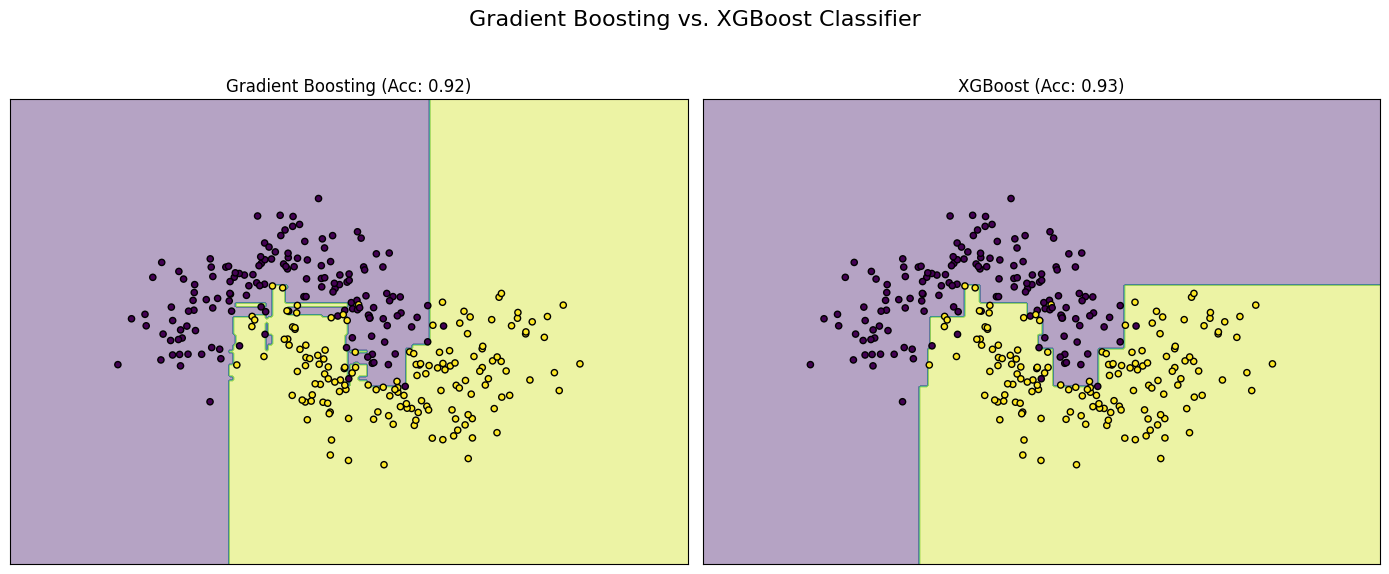

Accuracy of Gradient Boosting Classifier: 0.92
Accuracy of XGBoost Classifier: 0.93


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Define a function to plot decision boundaries
def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Gradient Boosting vs. XGBoost Classifier', fontsize=16)

# 1. Train a scikit-learn Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
plot_decision_boundary(gb_clf, X, y, axes[0], f'Gradient Boosting (Acc: {acc_gb:.2f})')

# 2. Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='logloss',    # Suppress warning for default eval_metric
    random_state=42
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
plot_decision_boundary(xgb_clf, X, y, axes[1], f'XGBoost (Acc: {acc_xgb:.2f})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Accuracy of Gradient Boosting Classifier: {acc_gb:.2f}")
print(f"Accuracy of XGBoost Classifier: {acc_xgb:.2f}")

## 7. LightGBM

### Definition
LightGBM (Light Gradient Boosting Machine) is an open-source distributed gradient boosting framework developed by Microsoft that uses tree-based learning algorithms. It is designed to be highly efficient, scalable, and faster than XGBoost, especially on large datasets. LightGBM introduces two main novel techniques: Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB), which significantly improve training speed without losing much accuracy.

### What's the Need?
While XGBoost brought significant improvements in performance and accuracy over traditional Gradient Boosting, it could still be slow and memory-intensive on very large datasets. LightGBM addresses these needs by focusing on:
1.  **Speed**: Faster training speed, often by an order of magnitude, compared to XGBoost.
2.  **Memory Efficiency**: Reduced memory usage, making it suitable for large datasets that might not fit into memory.
3.  **Scalability**: Distributed training capabilities for even larger datasets.
4.  **Accuracy**: Maintains comparable accuracy to XGBoost while offering substantial speed improvements.

### Math (Conceptual)
LightGBM, like XGBoost, builds an ensemble of decision trees sequentially, optimizing an objective function that includes a loss term and a regularization term. It also uses second-order gradients (Hessians). However, its primary optimizations come from how it constructs these trees and handles features.

Instead of growing trees 'level-wise' (like most decision tree implementations and traditional Gradient Boosting), LightGBM grows trees 'leaf-wise'. This means it finds the leaf that will result in the largest reduction in loss (gain) and grows that leaf, rather than growing all leaves at the same level. This can lead to deeper, more complex trees, but also to faster convergence.

Furthermore, LightGBM employs GOSS and EFB to efficiently handle data and features:
*   **GOSS (Gradient-based One-Side Sampling)**: Instead of using all data instances, GOSS keeps all instances with large gradients (those that are poorly trained) and randomly samples instances with small gradients (those that are well-trained), thereby focusing on more informative data for speed.
*   **EFB (Exclusive Feature Bundling)**: This technique bundles mutually exclusive features (features that rarely take non-zero values simultaneously) to reduce the number of features, thus speeding up training.

### Formula (General Objective)
The objective function for LightGBM is similar to XGBoost, involving the loss function $L$ and a regularization term $\Omega$. At iteration $t$, it minimizes:

$$\text{Obj}^{(t)} = \sum_{i=1}^{n} [g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i)] + \Omega(f_t)$$

Where $g_i$ and $h_i$ are the first and second-order gradients, and $f_t(x_i)$ is the new tree. The difference lies not in the objective itself, but in the *method* used to find the optimal $f_t$ (i.e., how the tree structure is grown and how the data/features are sampled).

### Visualization (Conceptual)
Imagine a large dataset. Traditional methods would analyze every data point and every feature at every step, which is like meticulously scanning every inch of a vast landscape. LightGBM, on the other hand, is like a smart explorer: it quickly identifies the most interesting (poorly classified) areas to focus its efforts (GOSS) and groups similar paths together to reduce redundant exploration (EFB). When building trees, instead of uniformly expanding all branches, it dives deep into the most promising branches first (leaf-wise growth), quickly reaching the most impactful splits.

### Advantages
*   **Significantly Faster Training**: Due to GOSS and EFB, it trains much faster than XGBoost and other GBDT frameworks.
*   **Lower Memory Usage**: EFB and other optimizations lead to reduced memory consumption.
*   **High Accuracy**: Achieves state-of-the-art accuracy, often comparable to or even better than XGBoost.
*   **Scalability**: Supports distributed training, making it suitable for very large datasets.
*   **Handles Categorical Features**: Can directly handle categorical features without requiring one-hot encoding, which can further speed up training and improve accuracy.

### Disadvantages
*   **Prone to Overfitting on Small Datasets**: Leaf-wise tree growth can lead to overfitting on small datasets. It's recommended to use it with a sufficiently large `num_leaves` parameter to control complexity.
*   **Sensitive to Hyperparameters**: Like other boosting methods, optimal performance requires careful tuning of hyperparameters.
*   **Data Size Requirement**: Best suited for datasets with a large number of instances and features. For very small datasets, other methods might be more stable.

### 7.1 Leaf-wise Growth (Best-first Search)

#### Definition
Leaf-wise (or best-first) tree growth is a tree construction strategy where, at each step, the algorithm identifies the leaf node that would yield the largest reduction in loss if split, and then performs the split on that specific leaf. This is in contrast to level-wise (or depth-first) growth, where all leaf nodes at the current level are split before moving to the next level.

#### What's the Need?
Traditional GBDT implementations (like early XGBoost versions) often use a level-wise approach. While this can lead to balanced trees, it can also be inefficient, as many splits in less informative parts of the tree might be processed. The need for leaf-wise growth arises from:
1.  **Faster Convergence**: By always splitting the leaf that promises the largest loss reduction, the algorithm can converge faster to a good solution.
2.  **Higher Accuracy**: For the same number of splits, leaf-wise growth can lead to deeper, more complex trees that capture more intricate patterns in the data, potentially resulting in higher accuracy.
3.  **Efficiency**: Avoids unnecessary splits in less important branches, focusing computational resources where they matter most.

#### How it Works
1.  **Start with Root**: The tree begins with a single root node.
2.  **Evaluate All Leaves**: At each iteration, the algorithm considers all existing leaf nodes and evaluates the potential gain (reduction in objective function) that would result from splitting each leaf.
3.  **Select Best Leaf**: The leaf node that offers the maximum gain is selected.
4.  **Split and Repeat**: This selected leaf is then split into two new leaf nodes, and the process repeats. The tree grows by continuously adding splits to the most beneficial leaves.

#### Visualization (Conceptual)
Imagine building a decision tree as a journey. Level-wise growth is like exploring every path at the same depth before going deeper on any specific path. Leaf-wise growth is like a skilled explorer who, at every crossroads, instantly knows which path looks most promising and immediately takes it, even if it leads far ahead of other paths, ensuring the most efficient route to the destination. This can lead to very asymmetrical trees.

#### Advantages
*   **More Efficient Splits**: Prioritizes splits that have the most impact on reducing the loss function.
*   **Faster Training**: Can often build accurate trees with fewer splits, leading to faster training times.
*   **Potentially Higher Accuracy**: Can capture more complex relationships within the same number of leaf nodes.

#### Disadvantages
*   **Prone to Overfitting on Small Datasets**: Because it can create very deep and asymmetrical trees, it can easily overfit on small datasets. This is typically controlled by limiting the `max_depth` or `num_leaves` parameters.
*   **Complexity Control**: Requires careful tuning of parameters like `num_leaves` to prevent overfitting.

### 7.2 Histogram-based Algorithm

#### Definition
The histogram-based algorithm is a technique used in LightGBM (and other gradient boosting frameworks like CatBoost) for finding optimal split points in decision trees. Instead of exhaustively scanning all possible split points for each feature (which can be very time-consuming for continuous features), it first bins continuous feature values into discrete bins or 'histograms'. Tree learners then use these discrete bins to find the best split points.

#### What's the Need?
Traditional tree algorithms, especially on datasets with many continuous features or large numbers of instances, can spend a significant amount of time sorting feature values to find optimal split points. The need for a histogram-based algorithm arises from:
1.  **Speed**: Dramatically speeds up the process of finding split points, especially for continuous features, by reducing the number of candidate split points.
2.  **Memory Efficiency**: Storing discrete bins (histograms) requires less memory than storing all individual feature values.
3.  **Parallelization**: Histograms can be constructed in parallel, further accelerating the training process.

#### How it Works
1.  **Binning**: For each continuous feature, the algorithm divides its range of values into a fixed number of discrete bins (e.g., 256 bins). Each data instance is then mapped to its corresponding bin.
2.  **Histogram Construction**: For each node in a decision tree, and for each feature, a histogram is constructed. This histogram accumulates the sum of gradients ($g_i$) and Hessians ($h_i$) for all instances falling into each bin.
3.  **Split Point Search**: To find the best split point, the algorithm iterates through these discrete bins. For a potential split between two bins, it can efficiently calculate the gain (reduction in loss) using the pre-computed sums of gradients and Hessians from the histograms. This is much faster than iterating through all unique feature values.

#### Visualization (Conceptual)
Imagine a long, continuous line representing a feature's values, and you need to find the best place to cut it. A brute-force approach would be to try cutting at every single distinct value. A histogram-based approach is like drawing a few markers on the line (bins) and only considering cuts at those markers. While you might miss a microscopically 'perfect' cut, you find a 'very good' cut much, much faster, with minimal impact on overall accuracy.

#### Advantages
*   **Significant Speed Up**: Reduces the computational cost of finding split points from $O(\#data \times \#features)$ to $O(\#bins \times \#features)$, making it much faster for large datasets.
*   **Reduced Memory Usage**: Storing histograms uses less memory than storing raw feature values and their sorted indices.
*   **Better Parallelization**: Histograms can be built independently for different features or data partitions, facilitating parallel training.
*   **Robust to Noise**: The binning process can make the algorithm more robust to minor noise in feature values.

#### Disadvantages
*   **Potential Loss of Precision**: Discretizing continuous features into bins might lead to a slight loss of information, potentially affecting the precise optimal split point. However, in practice, with a sufficient number of bins (e.g., 256), this loss is often negligible.
*   **Hyperparameter `num_bins`**: The number of bins can become another hyperparameter to tune, though default values are often good enough.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


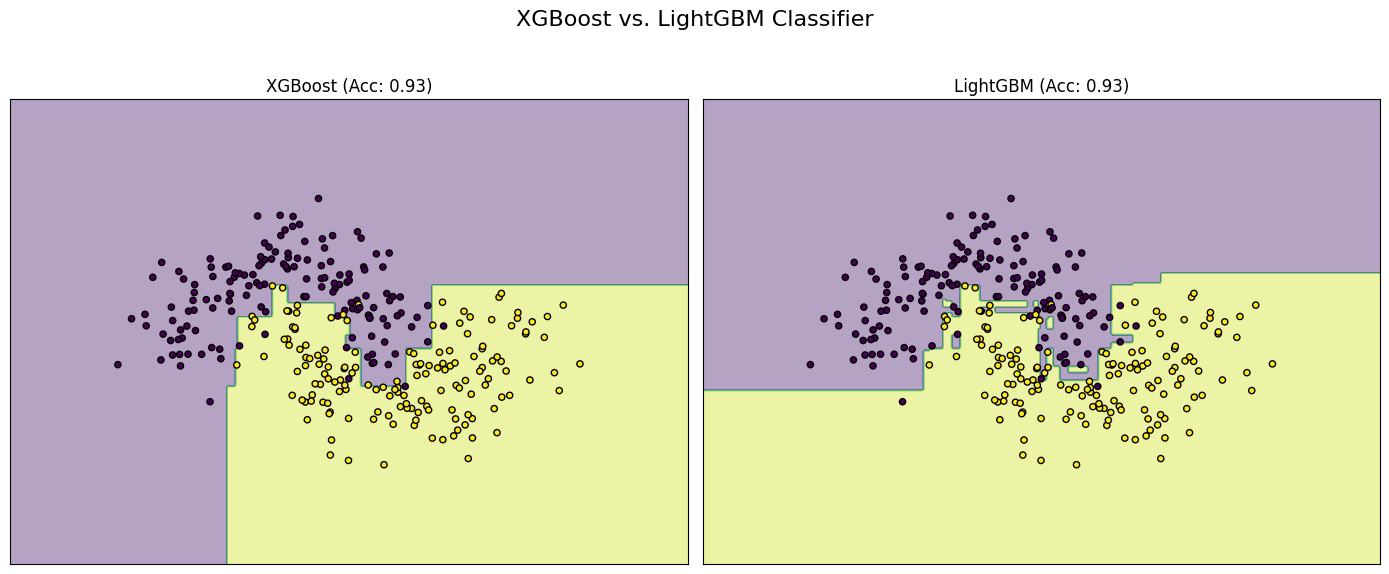

Accuracy of XGBoost Classifier: 0.93
Accuracy of LightGBM Classifier: 0.93


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Define a function to plot decision boundaries
def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('XGBoost vs. LightGBM Classifier', fontsize=16)

# 1. Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='logloss',
    random_state=42
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
plot_decision_boundary(xgb_clf, X, y, axes[0], f'XGBoost (Acc: {acc_xgb:.2f})')

# 2. Train a LightGBM Classifier
lgbm_clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,  # Default for LightGBM, often corresponds to max_depth
    max_depth=-1,   # No limit on tree depth unless num_leaves is set
    random_state=42,
    verbose=-1      # Suppress verbose output
)
lgbm_clf.fit(X_train, y_train)
y_pred_lgbm = lgbm_clf.predict(X_test)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
plot_decision_boundary(lgbm_clf, X, y, axes[1], f'LightGBM (Acc: {acc_lgbm:.2f})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Accuracy of XGBoost Classifier: {acc_xgb:.2f}")
print(f"Accuracy of LightGBM Classifier: {acc_lgbm:.2f}")